In [1]:
import sklearn
import torch

In [2]:
from sklearn.datasets import make_circles
from sklearn.datasets import make_moons

# say 1000 samples
X, y = make_circles(n_samples=1000, random_state=42, noise=0.03)

In [3]:
X.shape, y.shape, X[0:5], y[0:5]

((1000, 2),
 (1000,),
 array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

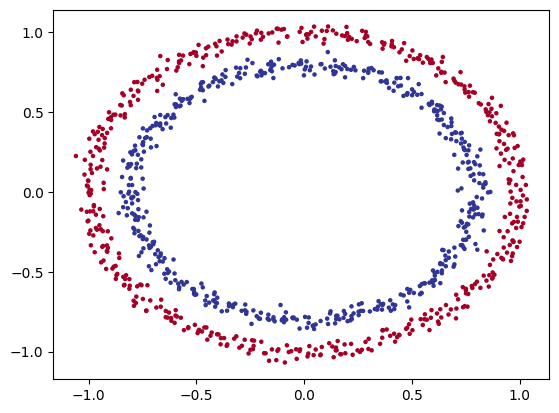

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], s=5, c=y, cmap=plt.cm.RdYlBu)

In [5]:
# put these values in pandas datadframe
import pandas as pd

In [6]:
circles = pd.DataFrame({"f1":X[:,0], "f2":X[:,1], "label":y})

In [7]:
circles.head()

,f1,f2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


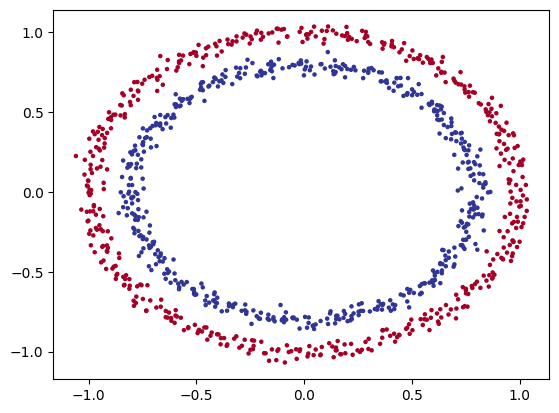

In [8]:
plt.scatter(circles['f1'], circles['f2'], c=circles['label'], cmap=plt.cm.RdYlBu, s=5)

In [9]:
circles[:5]

,f1,f2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [10]:
# numpy to tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [11]:
# train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,y, train_size=0.80, random_state=42)

In [12]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [13]:
from torch import nn

### make model
### 1. make subclass of nn
### 2. create 2 linear layer to handle shape of our data
### 3. define froward method



In [14]:
class CircleModel_0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, X):
        return self.layer2(self.layer1(X))
        

In [15]:
model_0 = CircleModel_0()

In [16]:
model_0,

(CircleModel_0(
   (layer1): Linear(in_features=2, out_features=5, bias=True)
   (layer2): Linear(in_features=5, out_features=1, bias=True)
 ),)

In [17]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.1862,  0.6080],
                      [ 0.1626,  0.0546],
                      [-0.5846, -0.4464],
                      [-0.3942,  0.3596],
                      [ 0.3848, -0.2098]])),
             ('layer1.bias',
              tensor([-0.0734, -0.3499, -0.1586,  0.4226, -0.3339])),
             ('layer2.weight',
              tensor([[-0.3290, -0.0554,  0.1654,  0.0897, -0.0450]])),
             ('layer2.bias', tensor([-0.2478]))])

In [18]:
model_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
)

In [19]:
model_1

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [20]:
model_1.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0044,  0.0771],
                      [ 0.2496, -0.5652],
                      [ 0.6224,  0.2435],
                      [ 0.2459,  0.3487],
                      [-0.4762, -0.4088]])),
             ('0.bias', tensor([ 0.7033, -0.4971,  0.3607,  0.5920, -0.3526])),
             ('1.weight',
              tensor([[ 0.2029, -0.4159, -0.3090,  0.1322, -0.3594]])),
             ('1.bias', tensor([-0.0801]))])

In [21]:
# make predictions | training is not yet done
# x_train
with torch.inference_mode():
    y_logits_untrained = model_0(x_test)
y_logits_untrained[:5]

tensor([[-0.3017],
        [-0.4049],
        [-0.0353],
        [-0.3772],
        [-0.0417]])

In [22]:
# apply sigmoid function
# from probabilities to laberls
y_untrained_preds = torch.sigmoid(y_logits_untrained)
y_untrained_preds[:5]

tensor([[0.4251],
        [0.4001],
        [0.4912],
        [0.4068],
        [0.4896]])

In [23]:
y_untrained_preds = torch.round(y_untrained_preds)
y_untrained_preds[:5]

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]])

In [24]:
# in singleline we can use 
y_untrained_preds = torch.round(torch.sigmoid(model_0(x_test)))
y_untrained_preds[:5]

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<SliceBackward0>)

In [25]:
# lets introdice loss fn and optimizers
loss_fn = nn.BCEWithLogitsLoss() # this loss is combines sigmoid and BCE loss in 1 single class
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [26]:
# setup evaluation matrix
def accurcy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc

## train model

In [27]:
epoch_list = []
train_loss_list = []
test_loss_list = []

torch.manual_seed(42)
epoches = 100
for epoch in range(epoches):
    epoch_list.append(epoch)
    
    #-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-TRAINING LOOP#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
    
    # 1. TRAINING | PUT MODEL IN TRAINING MODE
    model_0.train()

    # 2. FORWARD PASS
    y_logits_trained = model_0(x_train).squeeze() # model will start prediction here
    # y_preds_trained = torch.round(torch.sigmoid(y_logits_trained)) 

    # 3. LOSS CALCULATIONS | training loss
    # BCE_loss without logit loss will be something like this| expect probabilities not raw logits
    # loss = loss_fn(torch.sigmoid(y_logits_trained), y_train) 
    # we are using BCE_with_logit_loss so it expect raw logits
    train_loss = loss_fn(y_logits_trained, y_train) # BCE loss with logit loss | expect raw logits 
    # 3a. CALCULATE ACCURACY HERE | custom funtion | prebuilt can also be used 
    train_acc = accurcy_fn(y_true=y_train, y_pred=torch.round(torch.sigmoid(y_logits_trained))) # conversion of predictions -> probabilities -> labels
    train_loss_list.append(train_loss)
        
    # 4. zero the optimizers tensors
    optimizer.zero_grad()

    # 5. calculate the slopes/ gradients | back propagation
    train_loss.backward()
                     
    # 6. optimizer will calculate the changes | optimizer step
    optimizer.step()
        
    #-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-TESTING LOOP#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
    
    # 1. TESTING | PUT MODEL IN EVAL MODE
    model_0.eval()
    with torch.inference_mode():
        
    # 2. FORWARD PASS
        y_pred_test_logits = model_0(x_test).squeeze()
        # y_pred_test = torch.round(torch.sigmoid(y_pred_test_logits))

    # 3. LOSS CALCULATIONS | testing loss
        test_loss = loss_fn(y_pred_test_logits, y_test)
        test_acc = accurcy_fn(y_pred=torch.round(torch.sigmoid(y_pred_test_logits)), y_true=y_test)
        test_loss_list.append(test_loss)

    #-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-PRINT OUT LOOP#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#    
        
    if epoch % 10 == 0 :
        print(f'Epoch: {epoch} | Test_Loss: {train_loss:.5f} | Training_Acc:{train_acc:.5f}% | Test_Loss: {test_loss:.5f} | Test_Acc: {test_acc:.5f}%')



Epoch: 0 | Test_Loss: 0.70162 | Training_Acc:45.25000% | Test_Loss: 0.69491 | Test_Acc: 48.50000%
Epoch: 10 | Test_Loss: 0.69865 | Training_Acc:46.37500% | Test_Loss: 0.69255 | Test_Acc: 51.00000%
Epoch: 20 | Test_Loss: 0.69707 | Training_Acc:47.62500% | Test_Loss: 0.69153 | Test_Acc: 52.50000%
Epoch: 30 | Test_Loss: 0.69615 | Training_Acc:47.87500% | Test_Loss: 0.69112 | Test_Acc: 52.00000%
Epoch: 40 | Test_Loss: 0.69556 | Training_Acc:47.87500% | Test_Loss: 0.69099 | Test_Acc: 53.50000%
Epoch: 50 | Test_Loss: 0.69513 | Training_Acc:47.87500% | Test_Loss: 0.69100 | Test_Acc: 54.00000%
Epoch: 60 | Test_Loss: 0.69481 | Training_Acc:48.50000% | Test_Loss: 0.69108 | Test_Acc: 55.00000%
Epoch: 70 | Test_Loss: 0.69454 | Training_Acc:48.37500% | Test_Loss: 0.69120 | Test_Acc: 54.00000%
Epoch: 80 | Test_Loss: 0.69433 | Training_Acc:48.62500% | Test_Loss: 0.69133 | Test_Acc: 55.00000%
Epoch: 90 | Test_Loss: 0.69414 | Training_Acc:48.75000% | Test_Loss: 0.69147 | Test_Acc: 55.00000%


/home/aj/miniconda3/envs/genai/lib/python3.10/site-packages/torch/autograd/graph.py:841: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## make predictions

In [28]:
import numpy as np

In [29]:
# Plot linear data or training and test and predictions (optional)
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

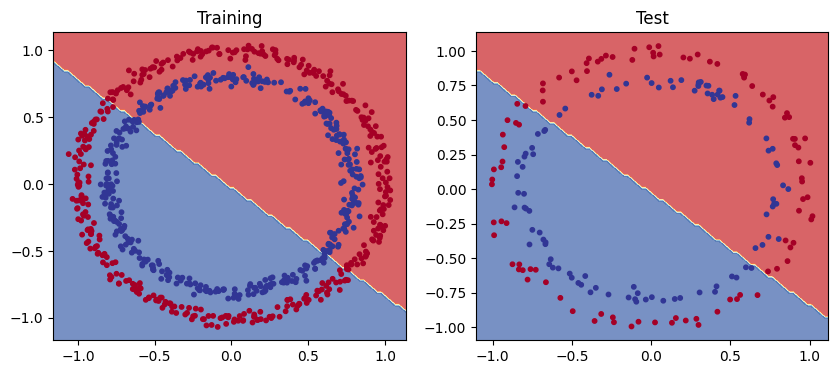

In [30]:
# observation: model is not learning anything
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Training')
plot_decision_boundary(model_0, x_train, y_train)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_0, x_test, y_test)

# IS THERE ANY CHANCE LINEAR LAYER CAN IMPROVE THE ACCURACY EVER

# IMPROVEMENT IN MODELS
# APPLY ONE BY ONE NOT ALL AT ONCE TO TRACK THE CHANGE
#### FROM MODELS PERSPECTIVE
#### 1.ADD MORE LAYERS (GIVE MODEL MORE CHANCE TO LEARN) | FROM 2 TO 5 LAYERS | 
#### 2.ADD MORE HIDDEN UNITS(NEURONS) | FROM 5 TO 10 
#### 3.ADD MORE EPOCHES | FROM 10 TO 100
#### 4.Change/add the activation function
#### 5.Change the learning rate (choose wisely leage cause overfitting small cause undefitting) | also cause vanishing gradient (gradient become zero too quickly)
#### 6.Change loss function

# Discussion:

* `1.Hidden layers increase` = depth (hierarchy of features) + Vanishing gradients
* `2.Neurons per layer increase` = width (capacity at one level) + Overfitting
* `3.Epochs increase` = time spent learning + Overfitting

||||||
|------------------|-------|-------|------|-----|
|1. ADDING MORE LAYERS|changes|example|effect|Risks|
|Depth = feature hierarchy|*Makes the model deeper|* Layer 1 → edges|* Can model complex non-linear relationships|Vanishing/exploding gradients|
||*Allows learning hierarchical representations|* Layer 2 → corners / textures|More expressive with fewer neurons|Harder to train|
||*Each layer learns features on top of previous features|* Layer 3 → shapes|Better for structured data (images, text, speech)|Overfitting if data is small|
||                                                       |* Layer 4 → objects||More compute|
|---------------------------------|---------------------------------|---------------------------------|---------------------------------|---------------------------------|
|2. ADDING MORE NEURONS|changes|example|effect|Risks|
|Think of neurons as basis functions |Increases capacity at a single representation level|Few neurons → simple curve|Learns finer details|Overfitting|
|Width = pattern diversity at one level|More neurons → more patterns captured in parallel|Many neurons → very flexible curve|Improves fit on complex data|Redundant neurons|
||||Easier to train than deep models|Slower inference|
|||||Poor generalization|
|---------------------------------|---------------------------------|---------------------------------|---------------------------------|---------------------------------|
|ADDING MORE EPOCH|changes|example|effect|Risks|
|More trainin gtime|Number of times the model sees the entire dataset|1 attempt → fall|Reduces training error|Overfitting|
||Improves weight optimization|100 attempts → balance|Allows convergence|Wasted compute|
|||10,000 attempts → perfect (or over-practice bad habits)|Necessary for deep models|Validation loss increases|
|||||Poor generalization|


* UNDERFITTING
  ↳ Add neurons OR layers OR epochs

* GOOD FIT
  ↳ Balance all three

* OVERFITTING
  ↳ Reduce neurons / layers / epochs
  ↳ Or add regularization

## Real life examples
||ImageNet CNNs|Tabular data|NLP Transformers|
|------------------|-------------|------------|----------------|
||Deep (50+ layers)|Shallow (1–3 layers)|Very deep|
||Moderate width|Wider layers|Very wide|
||Many epochs|Fewer epochs|Trained for many epochs on massive data|


### Mental model:
* `Layers`  → What kinds of features?
* `Neurons` → How many patterns?
* `Epochs`  → How well are weights tuned?

### Common mistake:
`“My model is bad, so I’ll add everything.”`
result:
* Slower training
* Worse generalization
* No insight into the problem

### solution:
* Increase capacity (layers/neurons) to reduce underfitting
* Increase epochs to reduce optimization error
* Always watch validation loss

In [39]:
# change in no of layers only
class CircleModel_01(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=10)
        self.layer2 = nn.Linear(in_features=10, out_features=10)
        self.layer3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, X):
        # z = self.layer1(X)
        # z = self.layer2(z)
        # z = self.layer3(z)
        # return(z)
        return self.layer3(self.layer2(self.layer1(X)))

model_01 = CircleModel_1()


In [33]:
model_01.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1310

In [35]:
# lets introdice loss fn and optimizers
loss_fn = nn.BCEWithLogitsLoss() # this loss is combines sigmoid and BCE loss in 1 single class
optimizer = torch.optim.SGD(params=model_01.parameters(), lr=0.1)

In [36]:
epoch_list = []
train_loss_list = []
test_loss_list = []

torch.manual_seed(42)
epoches = 1000
for epoch in range(epoches):
    epoch_list.append(epoch)
    
    #-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-TRAINING LOOP#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
    
    # 1. TRAINING | PUT MODEL IN TRAINING MODE
    model_01.train()

    # 2. FORWARD PASS
    y_logits_trained = model_0(x_train).squeeze() # model will start prediction here
    # y_preds_trained = torch.round(torch.sigmoid(y_logits_trained)) 

    # 3. LOSS CALCULATIONS | training loss
    # BCE_loss without logit loss will be something like this| expect probabilities not raw logits
    # loss = loss_fn(torch.sigmoid(y_logits_trained), y_train) 
    # we are using BCE_with_logit_loss so it expect raw logits
    train_loss = loss_fn(y_logits_trained, y_train) # BCE loss with logit loss | expect raw logits 
    # 3a. CALCULATE ACCURACY HERE | custom funtion | prebuilt can also be used 
    train_acc = accurcy_fn(y_true=y_train, y_pred=torch.round(torch.sigmoid(y_logits_trained))) # conversion of predictions -> probabilities -> labels
    train_loss_list.append(train_loss)
        
    # 4. zero the optimizers tensors
    optimizer.zero_grad()

    # 5. calculate the slopes/ gradients | back propagation
    train_loss.backward()
                     
    # 6. optimizer will calculate the changes | optimizer step
    optimizer.step()
        
    #-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-TESTING LOOP#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
    
    # 1. TESTING | PUT MODEL IN EVAL MODE
    model_01.eval()
    with torch.inference_mode():
        
    # 2. FORWARD PASS
        y_pred_test_logits = model_0(x_test).squeeze()
        # y_pred_test = torch.round(torch.sigmoid(y_pred_test_logits))

    # 3. LOSS CALCULATIONS | testing loss
        test_loss = loss_fn(y_pred_test_logits, y_test)
        test_acc = accurcy_fn(y_pred=torch.round(torch.sigmoid(y_pred_test_logits)), y_true=y_test)
        test_loss_list.append(test_loss)

    #-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-PRINT OUT LOOP#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#    
        
    if epoch % 10 == 0 :
        print(f'Epoch: {epoch} | Test_Loss: {train_loss:.5f} | Training_Acc:{train_acc:.5f}% | Test_Loss: {test_loss:.5f} | Test_Acc: {test_acc:.5f}%')



Epoch: 0 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 10 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 20 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 30 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 40 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 50 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 60 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 70 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 80 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 90 | Test_Loss: 0.69399 | Training_Acc:49.25000% | Test_Loss: 0.69159 | Test_Acc: 54.00000%
Epoch: 100 

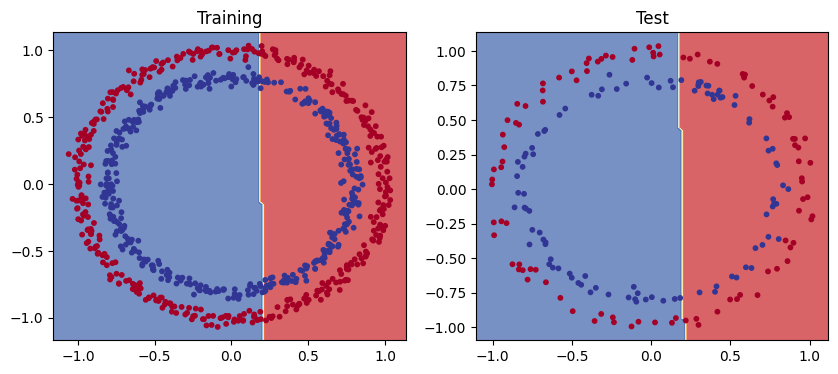

In [37]:
# observation: model is not learning anything
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Training')
plot_decision_boundary(model_01, x_train, y_train)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_01, x_test, y_test)

# what pattern you can draw with infitinite ammount of straignt and non straight lines.

## ml learns both linear and non linear patterns

In [41]:
# change in no of layers only
class CircleModel_02(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=10)
        self.layer2 = nn.Linear(in_features=10, out_features=10)
        self.layer3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, X):
        z = self.ReLU(self.layer1(X))
        z = self.ReLU(self.layer2(z))
        z = self.layer3(z)
        return(z)
        return self.layer3(self.ReLU(self.layer2(self.ReLU(self.layer1(X)))))

model_02 = CircleModel_02()